In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

## Initial Dataset Integrity Check

In [2]:
df = pd.read_csv('wages_1.csv')
df

,earn,height,sex,race,ed,age
0,79571.299011,73.89,male,white,16.0,49.0
1,96396.988643,66.23,female,white,16.0,62.0
2,48710.666947,63.77,female,white,16.0,33.0
3,80478.096153,63.22,female,other,16.0,95.0
4,82089.345498,63.08,female,white,17.0,43.0
...,...,...,...,...,...,...
1374,30173.380363,71.68,male,white,12.0,33.0
1375,24853.519514,61.31,female,white,18.0,86.0
1376,13710.671312,63.64,female,white,12.0,37.0
1377,95426.014410,71.65,male,white,12.0,54.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   earn    1319 non-null   float64
 1   height  1352 non-null   float64
 2   sex     1379 non-null   object 
 3   race    1379 non-null   object 
 4   ed      1356 non-null   float64
 5   age     1375 non-null   float64
dtypes: float64(4), object(2)
memory usage: 64.8+ KB


In [4]:
df = df.drop_duplicates()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   earn    1319 non-null   float64
 1   height  1352 non-null   float64
 2   sex     1379 non-null   object 
 3   race    1379 non-null   object 
 4   ed      1356 non-null   float64
 5   age     1375 non-null   float64
dtypes: float64(4), object(2)
memory usage: 64.8+ KB


In [6]:
df.isnull().sum()

earn      60
height    27
sex        0
race       0
ed        23
age        4
dtype: int64

In [7]:
df.isnull().mean()

earn      0.043510
height    0.019579
sex       0.000000
race      0.000000
ed        0.016679
age       0.002901
dtype: float64

In [8]:
filling_rate = 1 - df.isnull().mean()
filling_rate

earn      0.956490
height    0.980421
sex       1.000000
race      1.000000
ed        0.983321
age       0.997099
dtype: float64

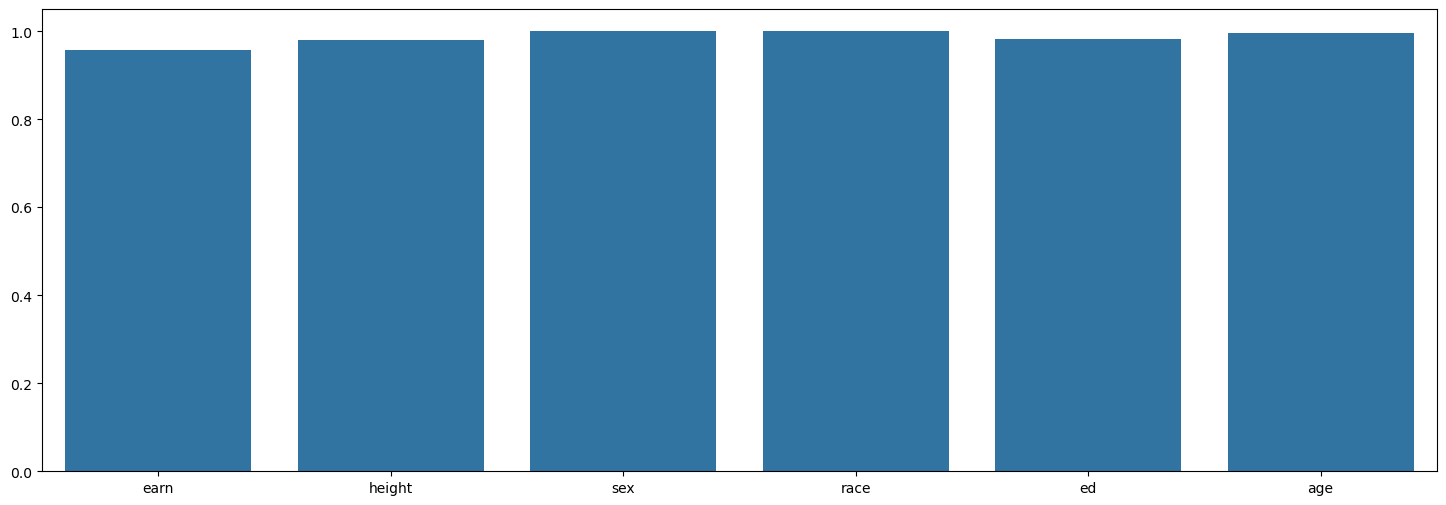

In [9]:
plt.figure(figsize=(18, 6))  # width, height in inches
sns.barplot(filling_rate)
plt.show()

## Data Preprocessing

The dataset was first examined using descriptive statistics to understand the distribution and range of numerical variables, including earnings, height, education, and age. The summary statistics revealed variation in earnings, with values ranging from 0 to approximately 198,835, indicating the presence of extreme values and potential skewness.

To ensure data quality, numerical variables were processed to remove invalid negative values. All negative values were replaced with zero using a clipping operation. This step ensures that variables such as earnings, height, education, and age remain within logically valid ranges and prevents negative values from affecting model training.

This preprocessing step improves data consistency and prepares the dataset for further analysis and regression modeling.

In [10]:
df.describe()

,earn,height,ed,age
count,1319.000000,1352.000000,1356.000000,1375.000000
mean,32347.317932,66.557626,13.350295,45.338909
std,30966.452437,3.791617,2.434471,15.793658
min,-98.580489,57.340000,3.000000,22.000000
25%,10538.672258,63.710000,12.000000,33.000000
50%,26930.543964,66.040000,13.000000,42.000000
75%,44506.215336,69.247500,15.000000,55.000000
max,317949.127955,77.210000,18.000000,95.000000


In [11]:
numCols = df.select_dtypes(include="number").columns
df[numCols] = df[numCols].clip(lower=0)

## Missing Value Imputation Using KNNImputer

To handle missing values in numerical features, the K-Nearest Neighbors (KNN) imputation method was applied. This approach replaces missing values by considering the values of the three nearest observations based on feature similarity.

The KNNImputer was configured with n_neighbors = 3, meaning that each missing value was estimated using the average of its three closest neighbors. This method preserves the underlying structure of the data and provides more accurate imputation compared to simple methods such as mean or median replacement.

This step ensures that the dataset contains no missing values and is suitable for regression modeling.


In [12]:
imputer = KNNImputer(n_neighbors=3)
df[numCols] = imputer.fit_transform(df[numCols])
df

,earn,height,sex,race,ed,age
0,79571.299011,73.89,male,white,16.0,49.0
1,96396.988643,66.23,female,white,16.0,62.0
2,48710.666947,63.77,female,white,16.0,33.0
3,80478.096153,63.22,female,other,16.0,95.0
4,82089.345498,63.08,female,white,17.0,43.0
...,...,...,...,...,...,...
1374,30173.380363,71.68,male,white,12.0,33.0
1375,24853.519514,61.31,female,white,18.0,86.0
1376,13710.671312,63.64,female,white,12.0,37.0
1377,95426.014410,71.65,male,white,12.0,54.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   earn    1379 non-null   float64
 1   height  1379 non-null   float64
 2   sex     1379 non-null   object 
 3   race    1379 non-null   object 
 4   ed      1379 non-null   float64
 5   age     1379 non-null   float64
dtypes: float64(4), object(2)
memory usage: 64.8+ KB


In [14]:
filling_rate = 1 - df.isnull().mean()
filling_rate

earn      1.0
height    1.0
sex       1.0
race      1.0
ed        1.0
age       1.0
dtype: float64

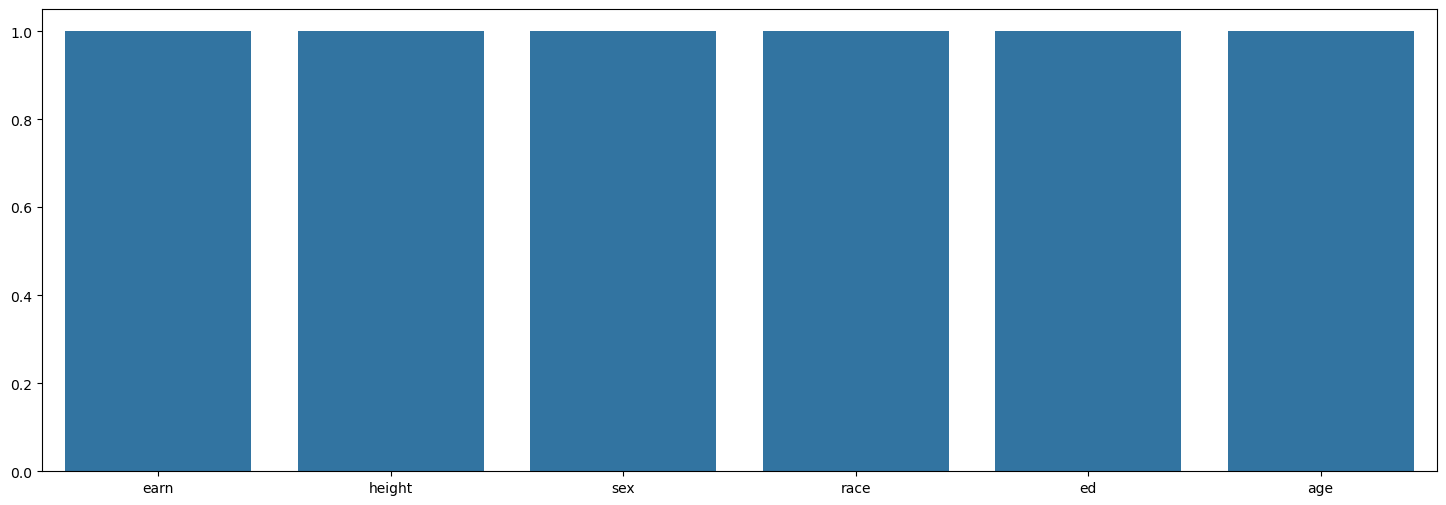

In [15]:
plt.figure(figsize=(18, 6))  # width, height in inches
sns.barplot(filling_rate)
plt.show()

## Explanatory Data Analysis (EDA)

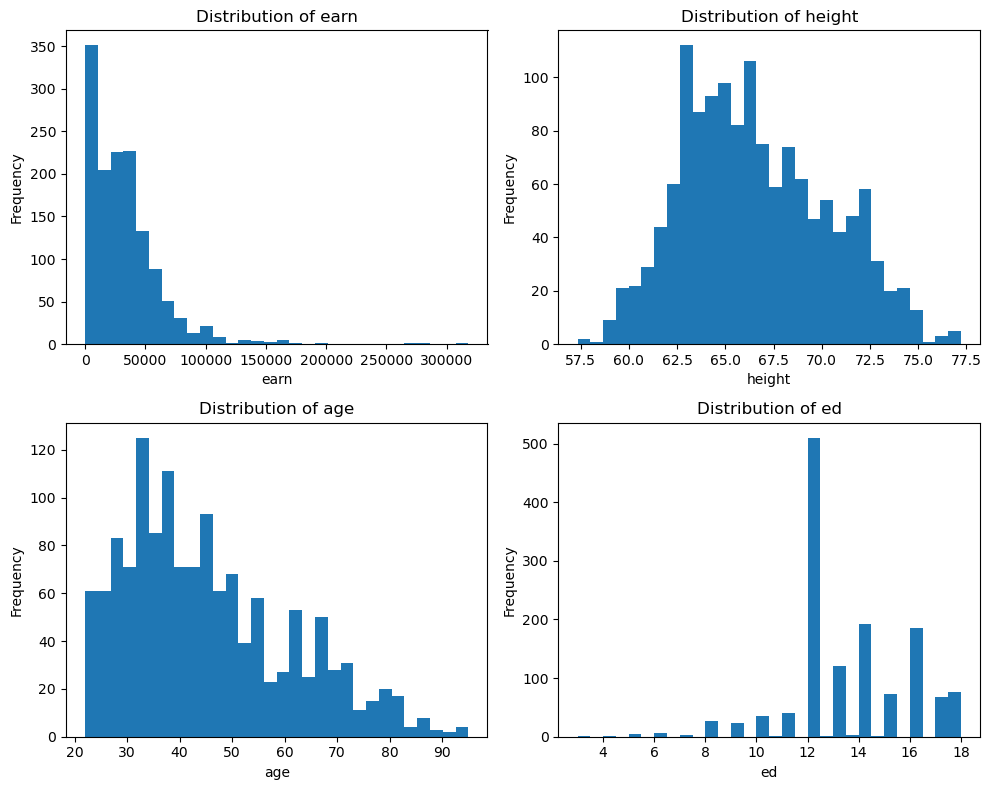

In [16]:
variables = ["earn", "height", "age", "ed"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes = axes.flatten()

for i, var in enumerate(variables):
    
    axes[i].hist(df[var], bins=30)
    
    axes[i].set_title(f"Distribution of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Distribution of Features

The earnings variable shows a strong right-skewed distribution, with most observations clustered at lower income levels and a small number of very high earners. This indicates the presence of outliers and a non-normal target distribution.

Height follows an approximately normal distribution, with values centered around the average and no significant skewness.

The age distribution is moderately spread, with most individuals falling between 25 and 60 years, representing the core working-age population.

Education (ed) appears concentrated at specific levels, reflecting common educational attainment such as high school and college degrees.

<Axes: xlabel='age', ylabel='Count'>

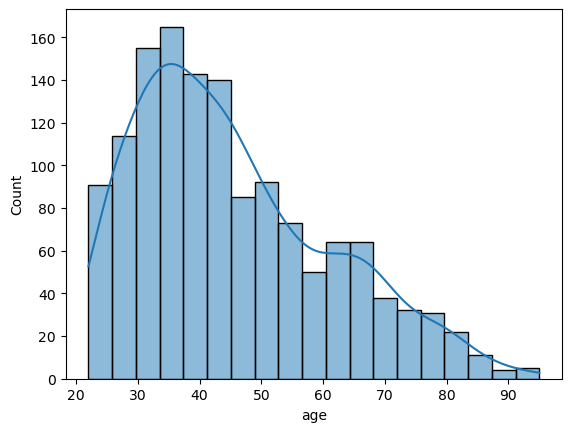

In [17]:
sns.histplot(data = df, x = "age", kde = True)

<Axes: xlabel='earn', ylabel='Count'>

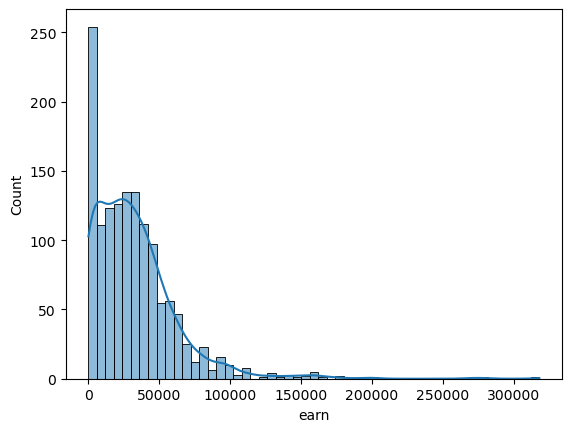

In [18]:
sns.histplot(data = df, x = "earn", kde = True)

<Axes: xlabel='ed', ylabel='Count'>

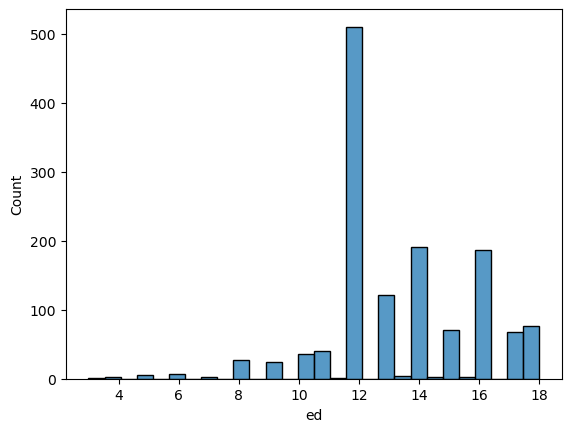

In [19]:
sns.histplot(data = df, x = "ed")

<Axes: xlabel='height', ylabel='Count'>

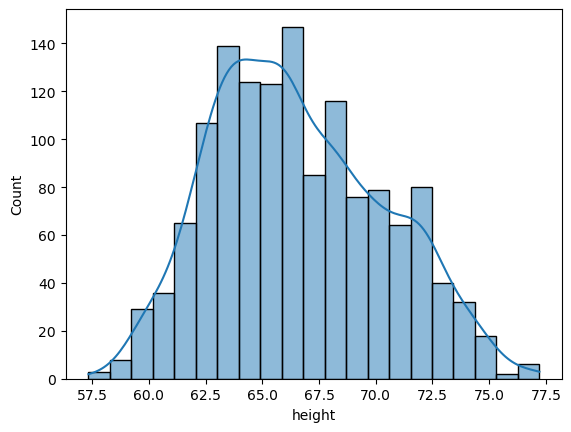

In [20]:
sns.histplot(data = df, x = "height", kde = True)

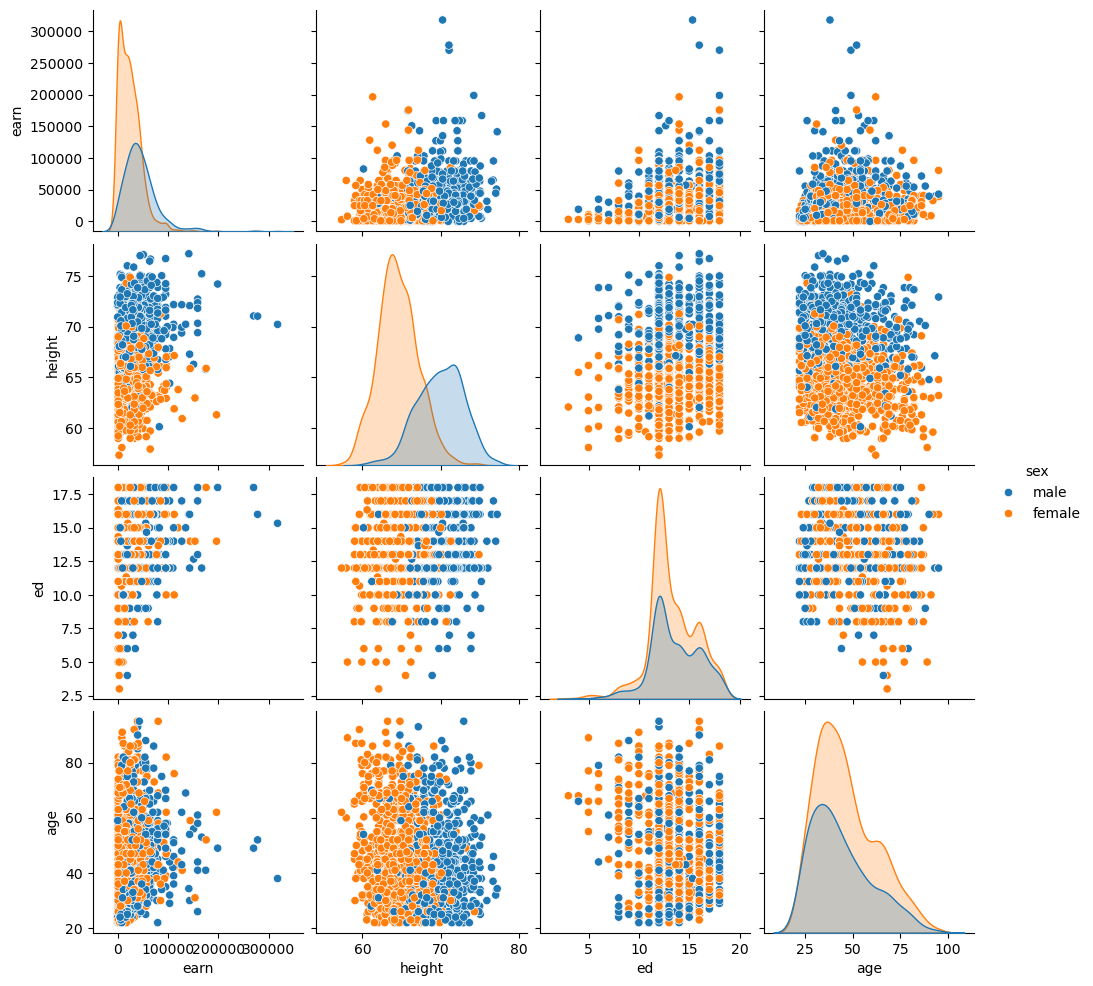

In [21]:
sns.pairplot(data = df, hue = "sex")

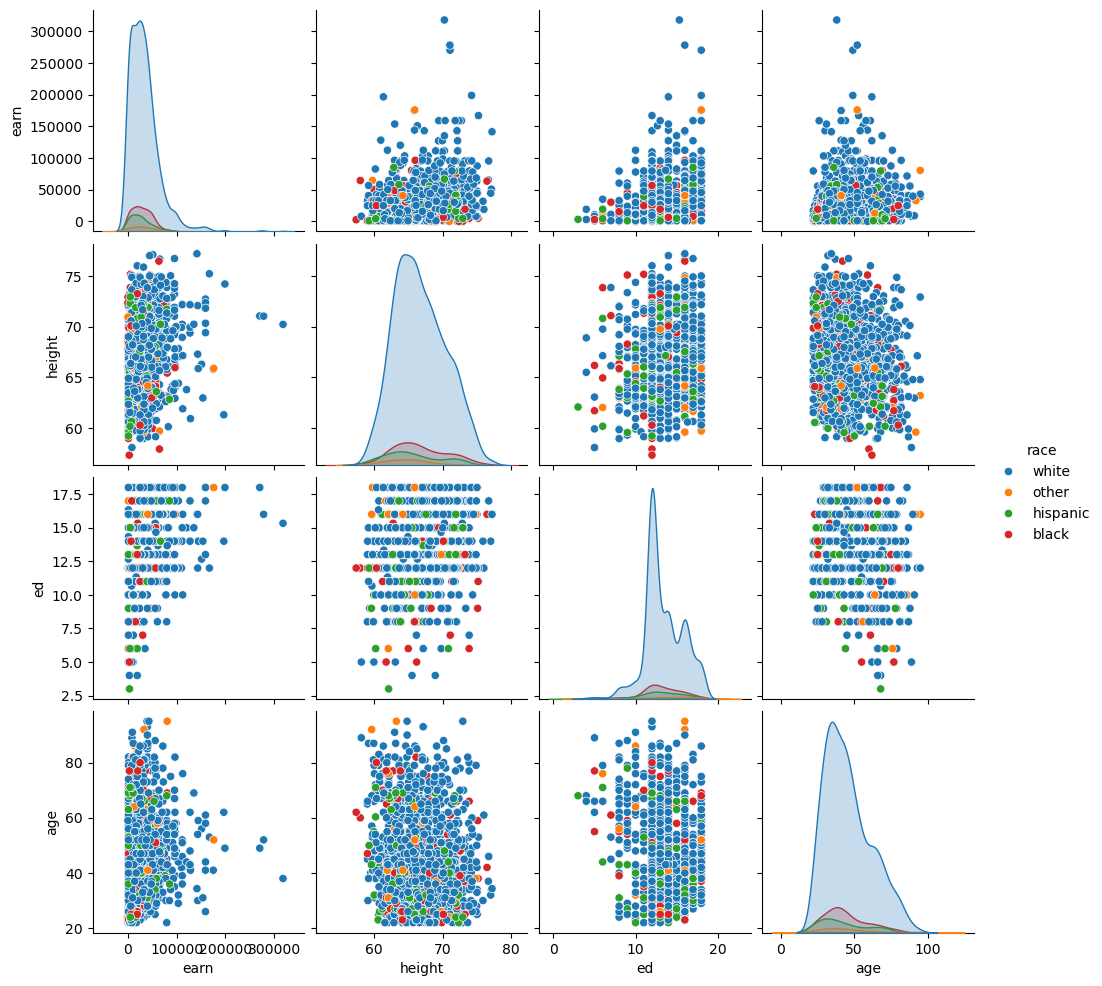

In [22]:
sns.pairplot(data = df, hue = "race")

<Axes: xlabel='race', ylabel='count'>

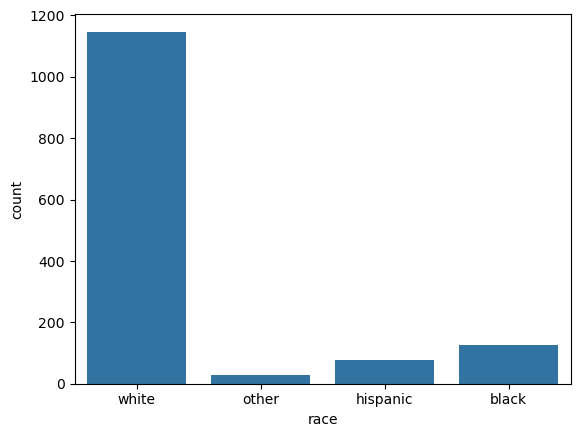

In [23]:
sns.countplot(data = df, x ="race")

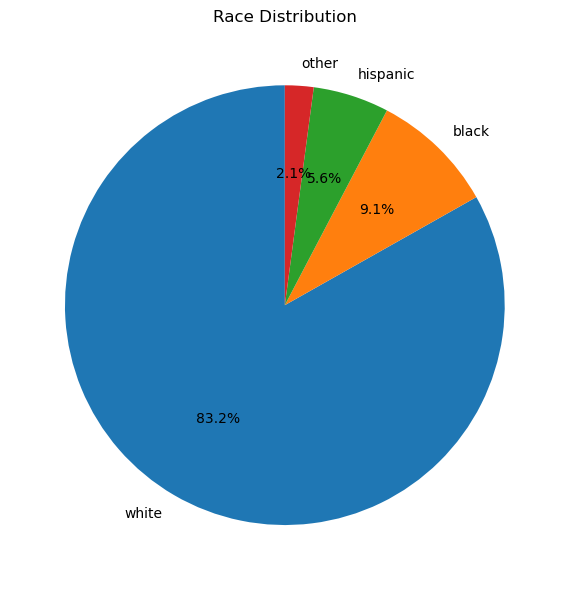

In [24]:
race = df["race"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    race.values,
    labels=race.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Race Distribution")
plt.tight_layout()
plt.show()

## Race Distribution Analysis

The race distribution shows that the majority of observations belong to the "white" category, while the "black" and "hispanic" categories represent a smaller portion of the dataset. The "other" category has very few observations.

This imbalance indicates that the dataset is dominated by one group, which may influence model learning and feature importance. As a result, race-related variables contribute less to the model compared to more informative features such as age and education.

In [25]:
# Discarding of race_other as the percentage is pretty low.
df = df[df["race"] != "other"]

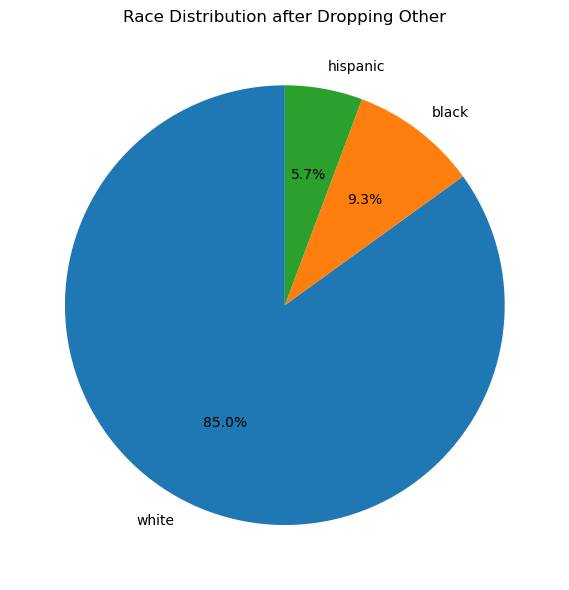

In [26]:
race = df["race"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    race.values,
    labels=race.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Race Distribution after Dropping Other")
plt.tight_layout()
plt.show()

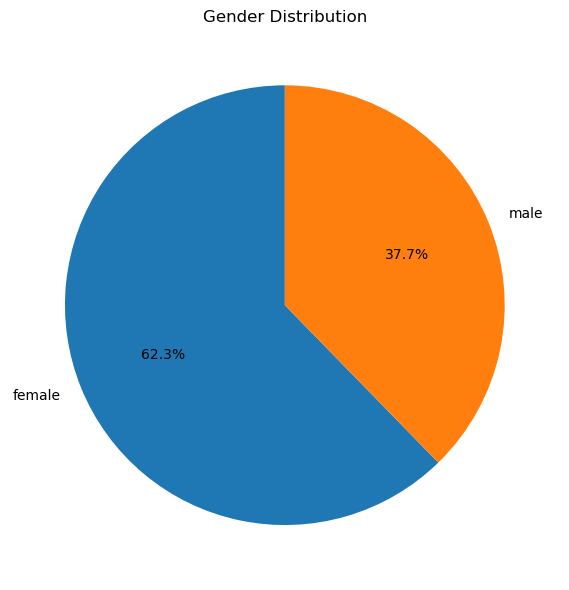

In [27]:
gender = df["sex"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

## Gender Distribution Analysis

The gender distribution shows that females represent approximately 62.3% of the dataset, while males account for about 37.7%. This indicates a moderate imbalance, with females being more prevalent in the sample.

Such imbalance may influence model training, as features associated with the majority group may have greater representation. However, since gender is included as a binary variable, the model can still effectively learn its relationship with earnings.

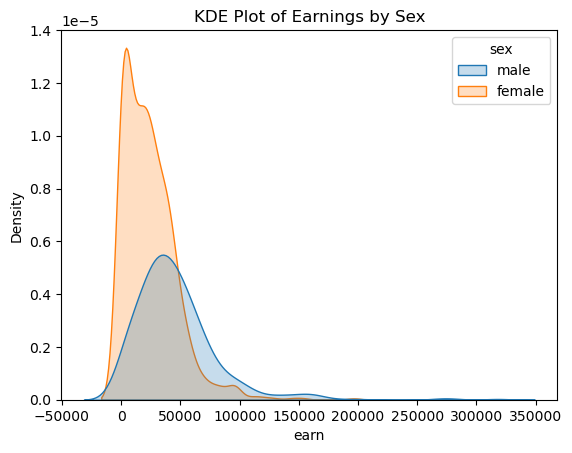

In [28]:
sns.kdeplot(data=df, x="earn", hue = "sex", fill = True)

plt.title("KDE Plot of Earnings by Sex")

plt.show()

## Earnings Distribution by Sex (KDE Plot)

The KDE plot illustrates the distribution of earnings for males and females. Both distributions are right-skewed, indicating that most individuals earn lower wages, with fewer individuals earning very high incomes.

The male earnings distribution is shifted toward higher values compared to females, suggesting that males tend to have higher earnings on average. Additionally, the male distribution shows a wider spread, indicating greater variability in earnings.

In contrast, female earnings are more concentrated within lower income ranges, with fewer observations at higher earnings levels. This difference in distribution suggests variation in earnings patterns between the two groups.


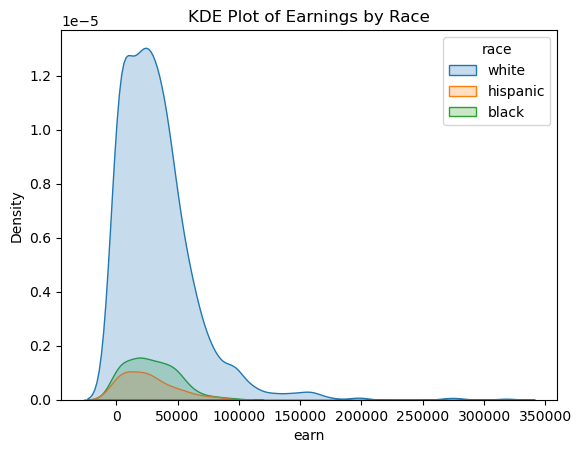

In [29]:
sns.kdeplot(data=df, x="earn", hue = "race", fill = True)

plt.title("KDE Plot of Earnings by Race")

plt.show()

## Earnings Distribution by Race (KDE Plot)

The KDE plot illustrates the distribution of earnings across different race groups. All distributions are right-skewed, indicating that most individuals earn lower wages, with fewer observations at higher income levels.

The white group shows a wider distribution and extends further into higher earnings ranges, indicating greater variability and the presence of more high-income observations. The black and hispanic groups display narrower distributions, with earnings more concentrated in lower to middle income ranges.

Overall, while the general shape of the distributions is similar, differences in spread and density reflect variation in earnings distribution across race groups within the dataset.

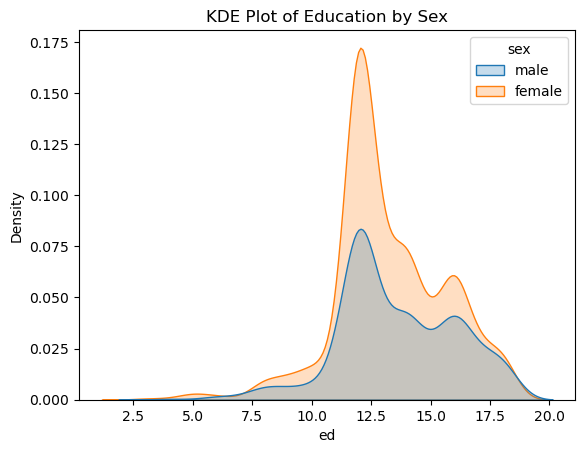

In [30]:
sns.kdeplot(data=df, x="ed", hue = "sex", fill = True)

plt.title("KDE Plot of Education by Sex")

plt.show()

## Education Distribution by Sex (KDE Plot)

The KDE plot shows the distribution of education levels for males and females. Both distributions are concentrated between approximately 10 and 18 years of education, indicating that most individuals fall within this range.

The female distribution has a higher peak around 12 years of education, suggesting a greater concentration of females at this level. The male distribution appears slightly more spread out across higher education levels, indicating greater variability.

Overall, the distributions are similar, but females show stronger concentration at specific education levels, while males exhibit slightly more dispersion across the education range.


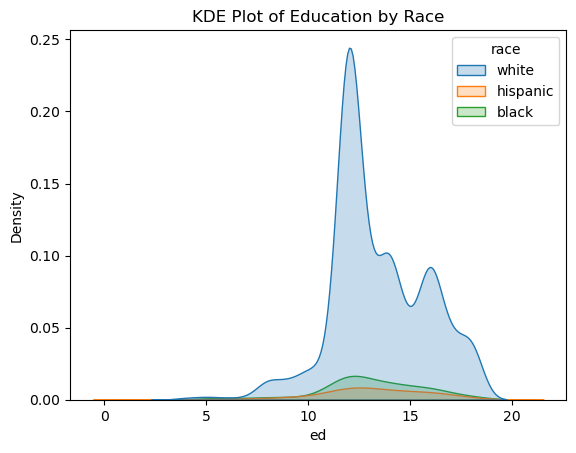

In [31]:
sns.kdeplot(data=df, x="ed", hue = "race", fill = True)

plt.title("KDE Plot of Education by Race")

plt.show()

## Education Distribution by Race (KDE Plot)

The KDE plot shows the distribution of education levels across different race groups. The white group has the highest density across most education levels, with a strong concentration around 12 to 16 years of education.

The black and hispanic groups show similar distribution patterns but with lower density levels, reflecting fewer observations in these categories. Their education levels are also concentrated around the same general range, though with less variation compared to the white group.

Overall, the plot indicates that education levels are centered around similar ranges across race groups, but the white group shows greater representation and variability in the dataset.


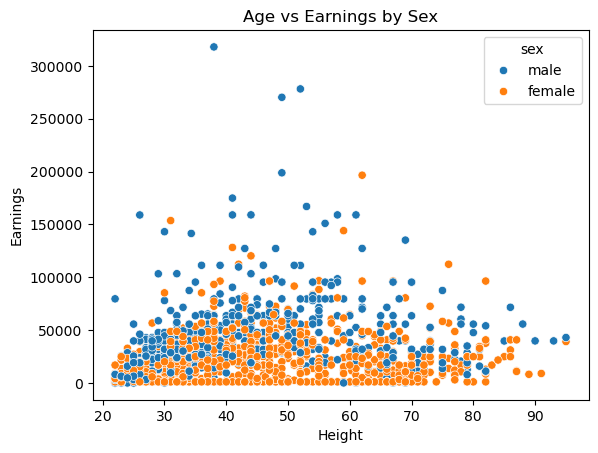

In [32]:
plt.figure()

sns.scatterplot(
    data=df,
    x="age",
    y="earn",
    hue="sex"
)

plt.title("Age vs Earnings by Sex")
plt.xlabel("Height")
plt.ylabel("Earnings")

plt.show()

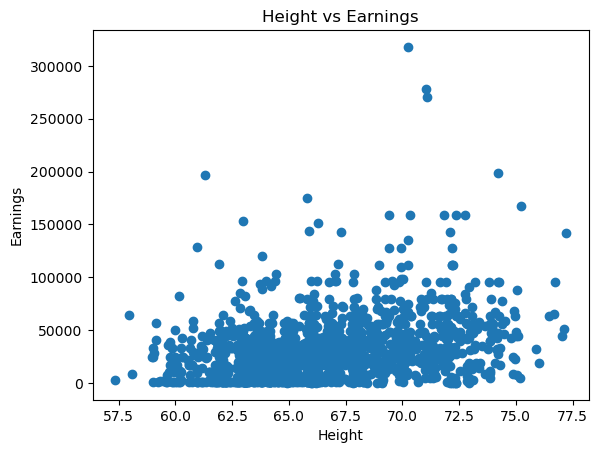

In [33]:
plt.figure()

plt.scatter(df["height"], df["earn"])

plt.title("Height vs Earnings")
plt.xlabel("Height")
plt.ylabel("Earnings")

plt.show()


In [34]:
rows_to_drop = df[(df["height"] > 70) & (df["earn"] > 250000)].index
df = df.drop(rows_to_drop)

## Height and Earnings Relationship with Outlier Handling

The scatter plot illustrates the relationship between height and earnings. Most observations are concentrated between 60 and 75 inches in height, with earnings primarily distributed below 100,000.

A small number of extreme observations with both very high height (>70 inches) and exceptionally high earnings (>250,000) were identified as outliers. These values can disproportionately influence model training and distort the relationship between variables.

To improve model robustness, these extreme observations were removed. This preprocessing step helps ensure that the model focuses on the general earnings pattern rather than being overly influenced by rare extreme cases.


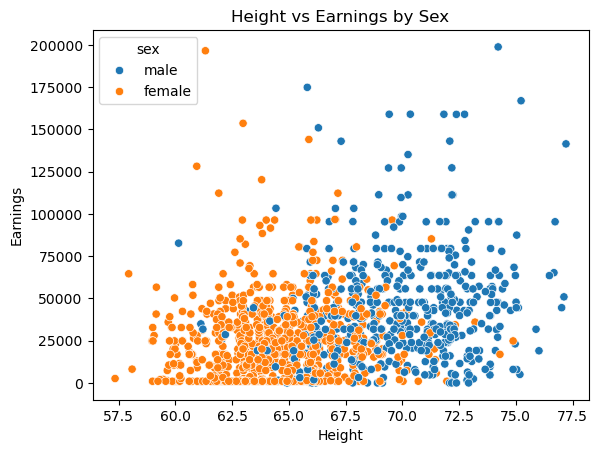

In [35]:
plt.figure()

sns.scatterplot(
    data=df,
    x="height",
    y="earn",
    hue="sex"
)

plt.title("Height vs Earnings by Sex")
plt.xlabel("Height")
plt.ylabel("Earnings")

plt.show()

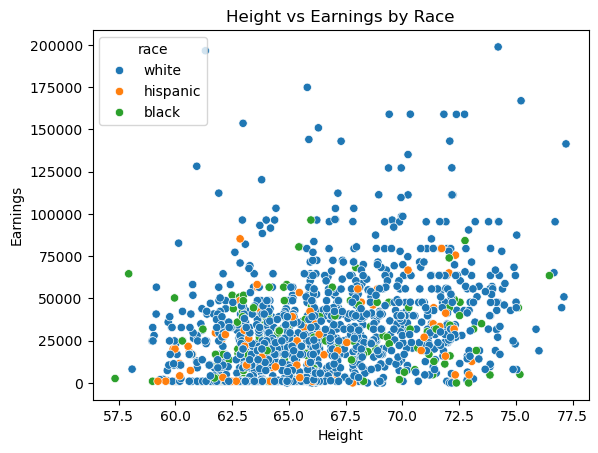

In [36]:
plt.figure()

sns.scatterplot(
    data=df,
    x="height",
    y="earn",
    hue="race"
)

plt.title("Height vs Earnings by Race")
plt.xlabel("Height")
plt.ylabel("Earnings")

plt.show()


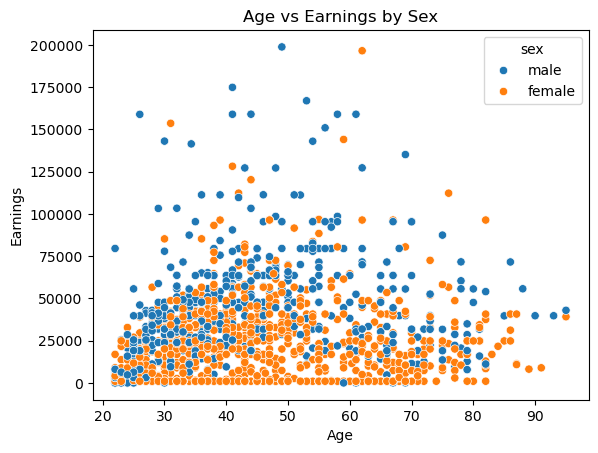

In [37]:
plt.figure()

sns.scatterplot(
    data=df,
    x="age",
    y="earn",
    hue="sex"
)

plt.title("Age vs Earnings by Sex")
plt.xlabel("Age")
plt.ylabel("Earnings")

plt.show()

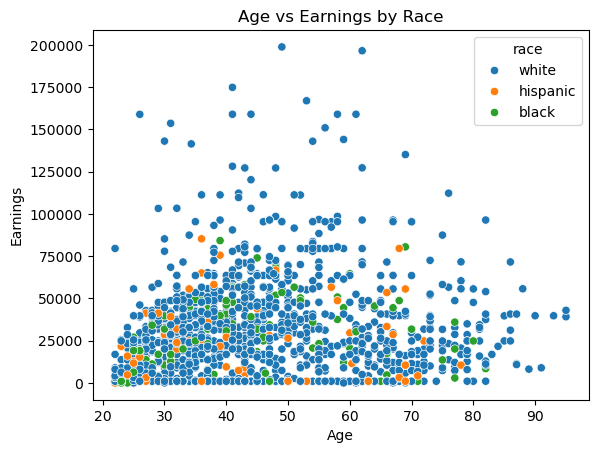

In [38]:
plt.figure()

sns.scatterplot(
    data=df,
    x="age",
    y="earn",
    hue="race"
)

plt.title("Age vs Earnings by Race")
plt.xlabel("Age")
plt.ylabel("Earnings")

plt.show()



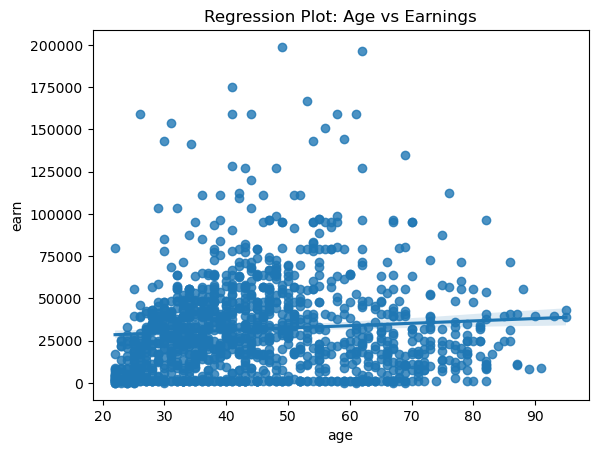

In [39]:
sns.regplot(data=df, x="age", y="earn")

plt.title("Regression Plot: Age vs Earnings")

plt.show()


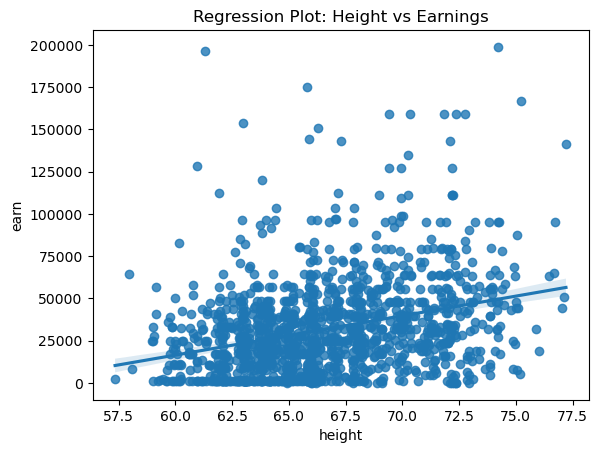

In [40]:
sns.regplot(data=df, x="height", y="earn")

plt.title("Regression Plot: Height vs Earnings")

plt.show()


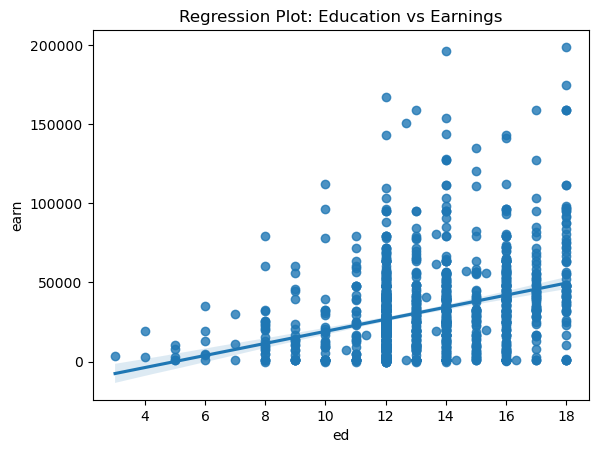

In [41]:
sns.regplot(data=df, x="ed", y="earn")

plt.title("Regression Plot: Education vs Earnings")

plt.show()

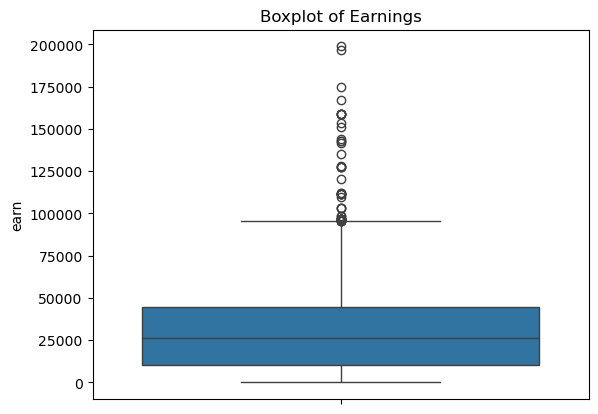

In [42]:
plt.figure()

sns.boxplot(y=df["earn"])

plt.title("Boxplot of Earnings")

plt.show()

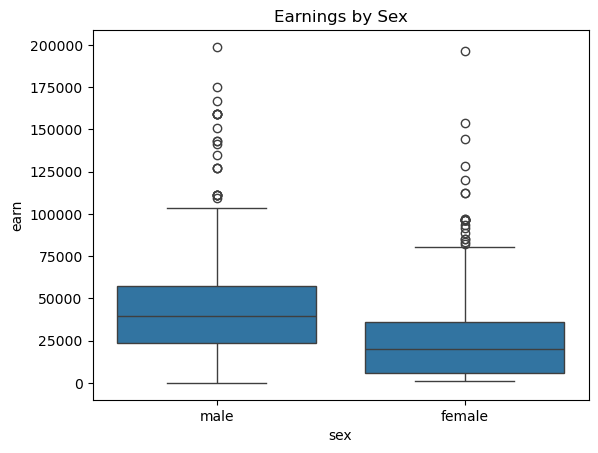

In [43]:
plt.figure()

sns.boxplot(data=df, x="sex", y="earn")

plt.title("Earnings by Sex")

plt.show()

## Earnings Distribution by Sex

The boxplot illustrates the distribution of earnings for males and females. The median earnings for males appear higher than those for females, indicating differences in central tendency between the two groups.

Additionally, the interquartile range (IQR) for males is wider, suggesting greater variability in earnings. Both groups show the presence of outliers, with several observations extending far beyond the upper quartile, reflecting extreme income values.

This visualization highlights differences in earnings distribution and variability between male and female individuals within the dataset.


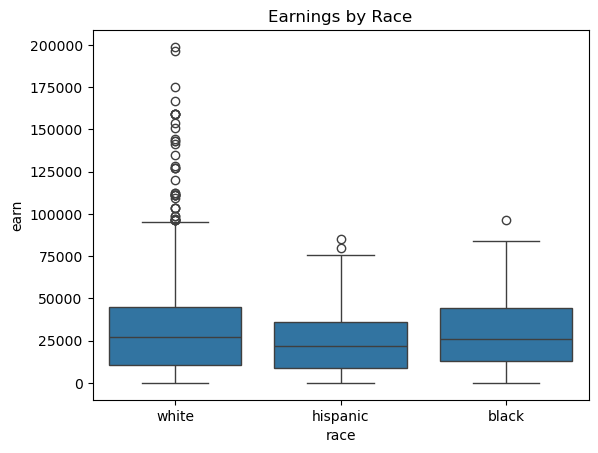

In [44]:
plt.figure()

sns.boxplot(data=df, x="race", y="earn")

plt.title("Earnings by Race")

plt.show()

## Earnings Distribution by Race

The boxplot presents the distribution of earnings across different race categories. The median earnings appear relatively similar across groups, although the white and black groups show slightly higher median values compared to the hispanic group.

The spread of earnings varies across races, with the white group exhibiting a wider range and more extreme outliers. This indicates greater variability in earnings within that group. All categories display outliers, reflecting the presence of individuals with significantly higher earnings than the majority.

These differences illustrate variations in earnings distribution, central tendency, and variability across racial groups within the dataset.


# Correlation of Numerical Variables (Target included)

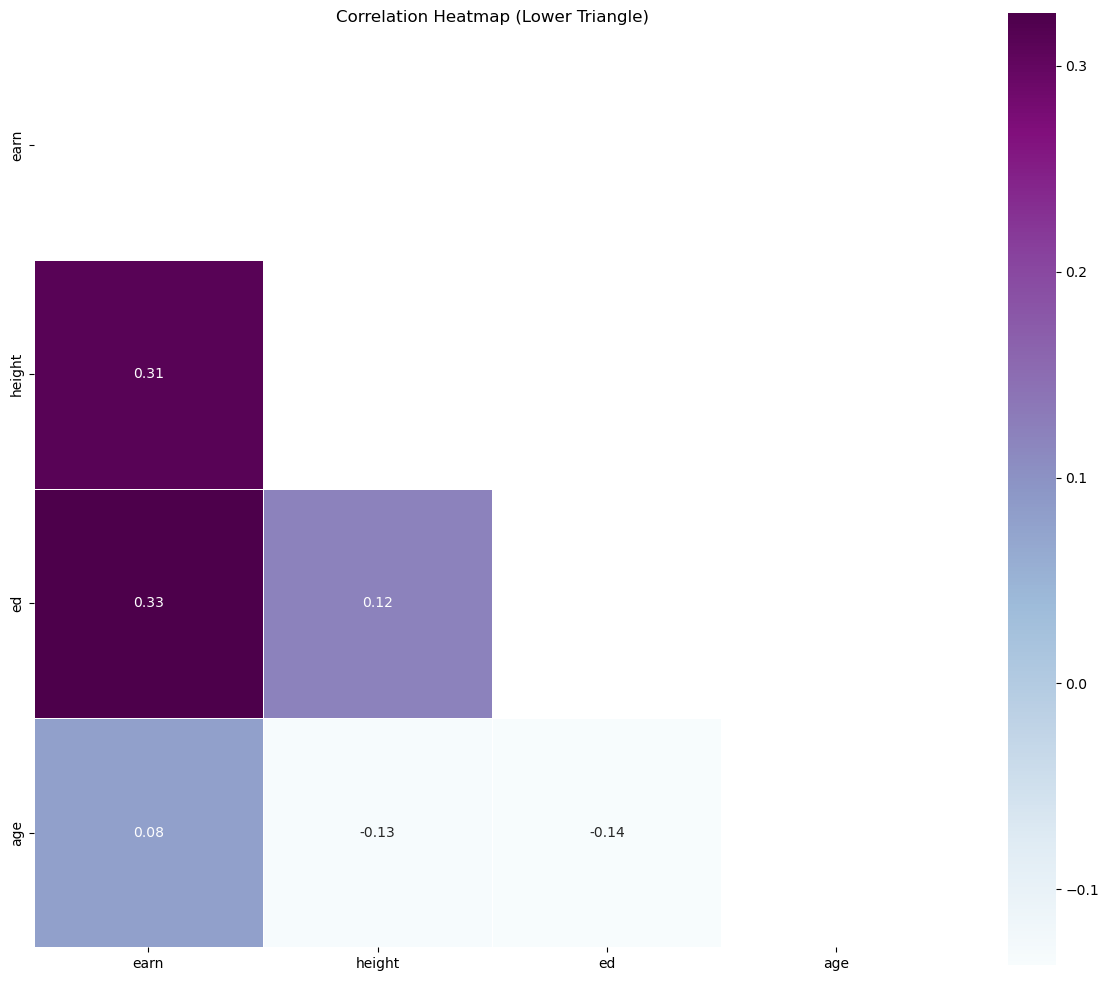

In [45]:
corr_with_target = df[numCols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_with_target, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_with_target,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="BuPu",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

## Correlation Analysis

The correlation heatmap shows the linear relationships between earnings and the numerical features.

Education (0.33) and height (0.31) show the strongest positive correlations with earnings, indicating that higher education levels and greater height are associated with higher earnings. Age shows a weak positive correlation with earnings (0.08), suggesting only a minor linear relationship.

The correlations between predictors themselves are relatively low, with slight negative relationships between age and both height (-0.13) and education (-0.14). This indicates low multicollinearity among the independent variables, which is beneficial for regression modeling.

Overall, education and height appear to be the most relevant numerical predictors of earnings among the variables analyzed.


# One-Hot Encoding and Elaborated Correlation Analysis

In [46]:
df.select_dtypes(include="object").columns

Index(['sex', 'race'], dtype='object')

In [47]:
df_encoded = pd.get_dummies(df, columns=["sex", "race"], dtype = int)

df_encoded.head()

,earn,height,ed,age,sex_female,sex_male,race_black,race_hispanic,race_white
0,79571.299011,73.890000,16.0,49.0,0,1,0,0,1
1,96396.988643,66.230000,16.0,62.0,1,0,0,0,1
2,48710.666947,63.770000,16.0,33.0,1,0,0,0,1
4,82089.345498,63.080000,17.0,43.0,1,0,0,0,1
5,15313.352901,69.986667,15.0,30.0,1,0,0,0,1


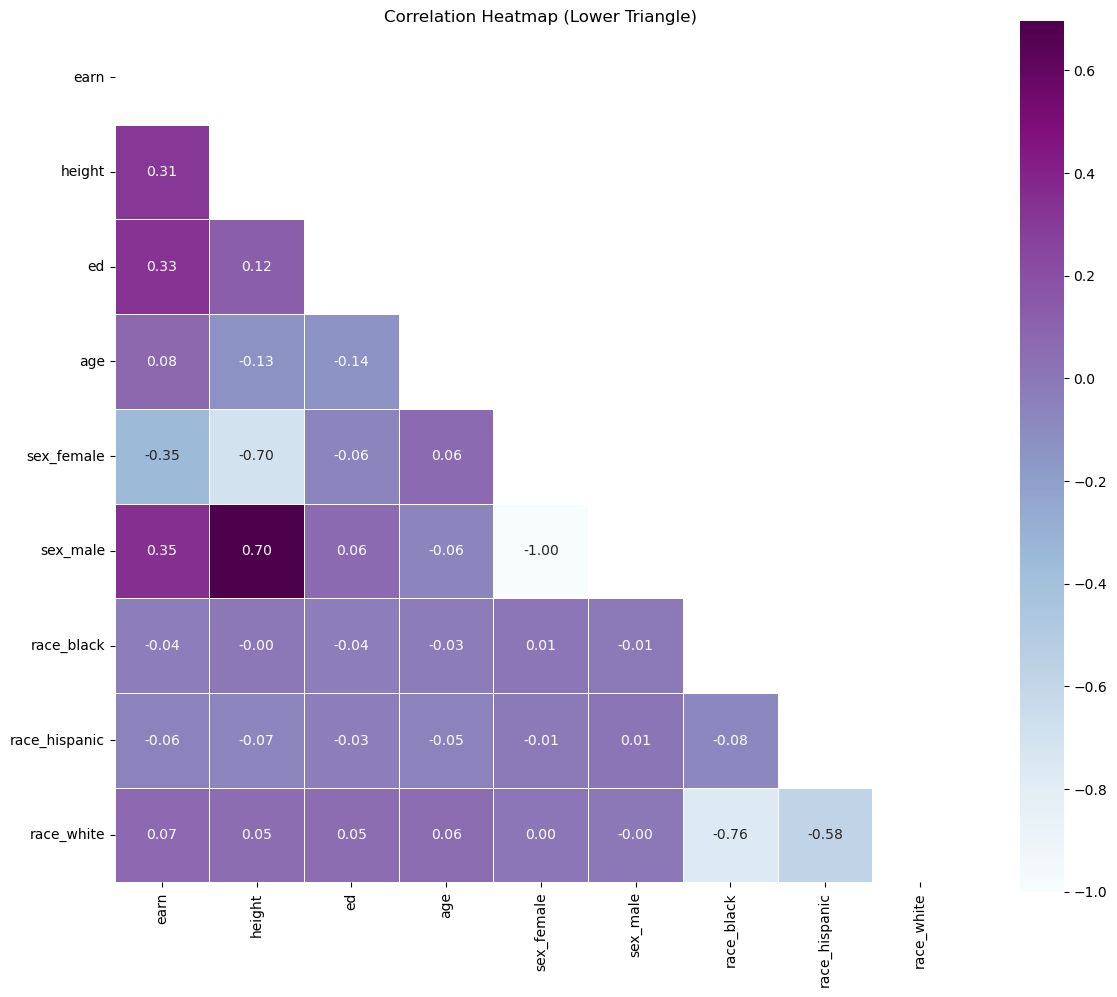

In [48]:
corr_with_target_encoded = df_encoded.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_with_target_encoded, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_with_target_encoded,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="BuPu",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

## Correlation Analysis with Encoded Variables

The correlation heatmap shows the relationships between earnings and both numerical and encoded categorical variables. Education (0.33), height (0.31), and sex_male (0.35) exhibit the strongest positive correlations with earnings, indicating that these variables are associated with higher income levels. In contrast, sex_female shows a moderate negative correlation with earnings (-0.35), reflecting the inverse relationship due to binary encoding.

Age shows only a weak positive correlation with earnings (0.08), suggesting limited predictive strength as a standalone variable. Race variables show very weak correlations with earnings, indicating that race contributes less strongly to earnings prediction compared to education, height, and sex.

Strong negative correlations between binary variables such as sex_male and sex_female (-1.00) and between race categories are expected due to one-hot encoding, where categories are mutually exclusive. Overall, education, height, and sex appear to be the most influential predictors of earnings among the available features.


# Pipeline of Regression Models (Linear Regression, Ridge, Gradient Boosting, Random Forest)

## train_test_split

In [49]:
# Define features and target
X = df.drop("earn", axis=1)
y = df["earn"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)
num_features = ["height", "ed", "age"]
cat_features = ["sex", "race"]

## Initialization of Pipeline Method (Standard Scaling, One-Hot Encoding, Column Transforming)

In [50]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", sparse_output=False, dtype=int, handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ],
    remainder="drop"
)

## Initialization of Models with Parameters

In [51]:
models = {
    
    "Linear": {
        "model": LinearRegression(),
        "params": {}
    },

    "Ridge": {
        "model": Ridge(random_state=42),
        "params": {
            "model__alpha": np.logspace(-4, 4, 100),
            "model__solver": ["auto", "svd", "cholesky", "lsqr", "sag"],
            "model__fit_intercept": [True, False]
        }
    },

    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [300, 500, 800],
            "model__learning_rate": [0.01, 0.03, 0.05],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [5, 10, 20],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__max_features": [None, "sqrt"]
        }
    },
    
     "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 10],
            "model__min_samples_leaf": [1, 5],
            "model__max_features": ["sqrt", 1.0],
            "model__bootstrap": [True, False]
        }
    }
}

## Model Scores via GridSearch

In [52]:
results = {}

for name, config in models.items():
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", config["model"])
    ])
    
    grid = GridSearchCV(
        pipe,
        config["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    train_score = r2_score(y_train, y_train_pred)
    test_score = r2_score(y_test, y_test_pred)
    
    cv_score = grid.best_score_
    
    results[name] = {
        "model": best_model,
        "best_params": best_params,
        "train_score": train_score,
        "test_score": test_score,
        "cv_score": cv_score
    }
    
    print(name)
    print("Best Params:", best_params)
    print("Train R2:", train_score)
    print("Test R2:", test_score)
    print("CV R2:", cv_score)
    print("-----------")

Linear
Best Params: {}
Train R2: 0.24485273367769933
Test R2: 0.2261347351447981
CV R2: 0.23580465452285174
-----------
Ridge
Best Params: {'model__alpha': np.float64(4.862601580065354), 'model__fit_intercept': True, 'model__solver': 'sag'}
Train R2: 0.24477431165537578
Test R2: 0.22769087020210832
CV R2: 0.23594677148922885
-----------
GradientBoosting
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 800, 'model__subsample': 0.6}
Train R2: 0.40631359940340517
Test R2: 0.2831696535214048
CV R2: 0.311084383666289
-----------
RandomForest
Best Params: {'model__bootstrap': True, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Train R2: 0.48962365109736283
Test R2: 0.275003152560618
CV R2: 0.28745540395684366
-----------


In [53]:
pd.set_option('display.max_colwidth', None)

In [54]:
summary = pd.DataFrame({
    name: {
        "Train R2": results[name]["train_score"],
        "Test R2": results[name]["test_score"],
        "CV R2": results[name]["cv_score"],
        "Best Params": results[name]["best_params"]
    }
    for name in results
}).T

summary

,Train R2,Test R2,CV R2,Best Params
Linear,0.244853,0.226135,0.235805,{}
Ridge,0.244774,0.227691,0.235947,"{'model__alpha': 4.862601580065354, 'model__fit_intercept': True, 'model__solver': 'sag'}"
GradientBoosting,0.406314,0.28317,0.311084,"{'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 800, 'model__subsample': 0.6}"
RandomForest,0.489624,0.275003,0.287455,"{'model__bootstrap': True, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}"


## Selection of the Best Model

In [55]:
best_model_name = max(results, key=lambda x: results[x]["cv_score"])
best_model = results[best_model_name]["model"]

print("Best Model:", best_model_name)

Best Model: GradientBoosting


## Model Performance Comparison

The performance of the Linear Regression, Ridge, Gradient Boosting, and Random Forest models was evaluated using Train R², Test R², and Cross-Validation (CV) R² scores.

Among all models, Gradient Boosting achieved the highest Cross-Validation R² score (0.311), indicating the best generalization performance on unseen data. It also produced the highest Test R² score (0.283), showing improved predictive accuracy compared to the other models.

Random Forest showed a higher Train R² score (0.490), but its lower CV R² score (0.287) suggests a greater tendency to overfit the training data. Linear Regression and Ridge Regression showed lower and nearly identical performance, indicating limited ability to capture nonlinear relationships in the data.

These results demonstrate that **Gradient Boosting** provides the most balanced performance between model fit and generalization.


## Residuals and Predictions of the Best Model (Gradient Boosting)

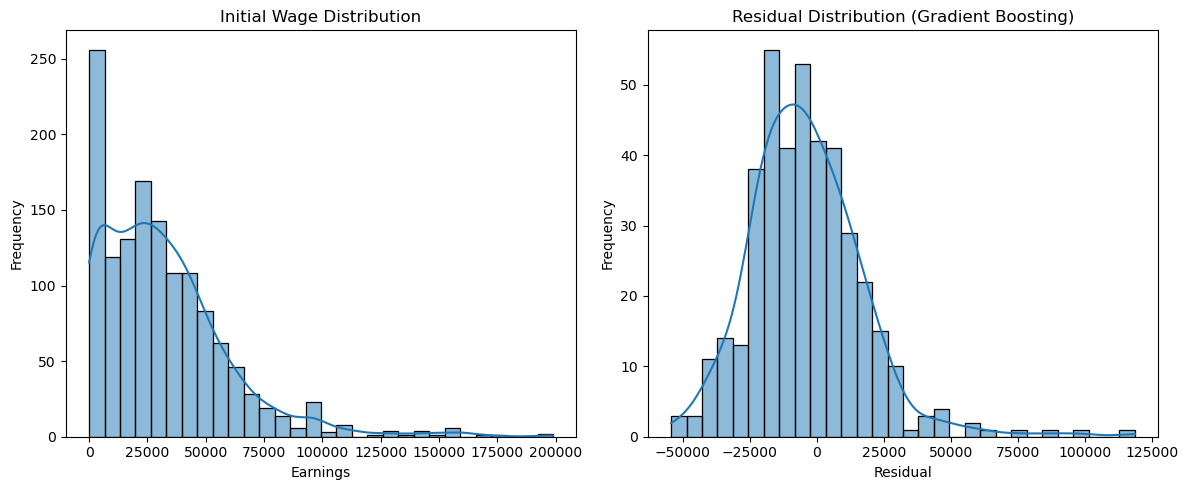

In [56]:
y_pred = best_model.predict(X_test)

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df["earn"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Initial Wage Distribution")
axes[0].set_xlabel("Earnings")
axes[0].set_ylabel("Frequency")

sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution (Gradient Boosting)")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Wage and Residual Distribution Analysis

The initial wage distribution is strongly right-skewed, with most observations concentrated at lower income levels and a long tail extending toward higher earnings. This indicates the presence of high-income outliers and a non-normal distribution of the target variable.

The residual distribution of the Gradient Boosting model is centered around zero and shows an approximately symmetric shape. This suggests that the model does not exhibit strong systematic bias and that prediction errors are relatively balanced. However, the presence of some large residual values indicates that the model has greater difficulty predicting extreme earnings values.


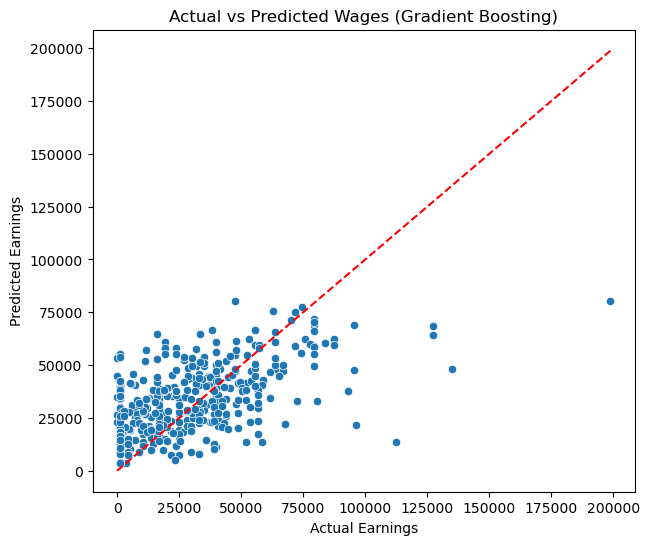

In [57]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(7,6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Wages (Gradient Boosting)")
plt.xlabel("Actual Earnings")
plt.ylabel("Predicted Earnings")

plt.show()

## Actual vs Predicted Earnings (Gradient Boosting)

The scatter plot compares actual earnings with predicted earnings from the Gradient Boosting model. The red diagonal line represents perfect prediction, where predicted values equal actual values.

Most observations are clustered around the diagonal line, indicating that the model captures the general relationship between predictors and earnings. However, as actual earnings increase, the spread of points becomes larger, suggesting reduced prediction accuracy for higher-income individuals.

This pattern indicates that while the model performs well for lower and moderate earnings, it tends to underestimate extreme high earnings and shows greater variability in predictions for these cases.


## Feature Importances of the Best Model (Gradient Boosting)

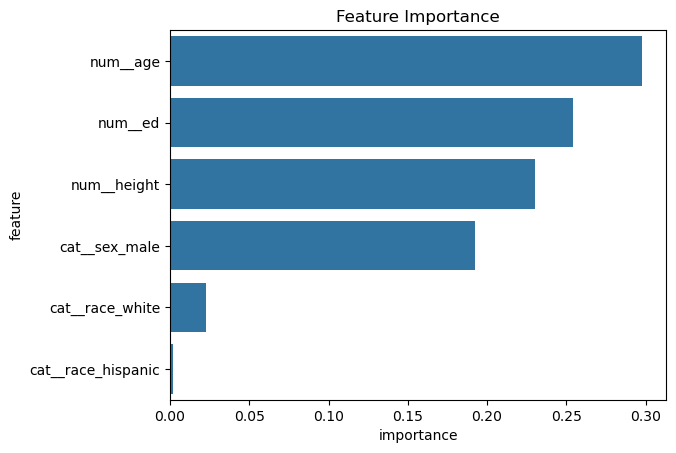

In [58]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

if hasattr(best_model.named_steps["model"], "feature_importances_"):

    importances = best_model.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    sns.barplot(data=importance_df, x="importance", y="feature")

    plt.title("Feature Importance")
    plt.show()


## Feature Importance Analysis (Gradient Boosting)

The feature importance plot shows the relative contribution of each predictor to the Gradient Boosting model.

Age appears as the most important feature, followed by education and height, indicating that these numerical variables have the strongest influence on earnings prediction. The sex_male variable also contributes moderately to the model, suggesting that gender-related differences are captured in the predictions.

Race-related variables, such as race_white and race_hispanic, show very low importance, indicating that they contribute minimally to the model’s predictive performance. Overall, numerical features play a dominant role compared to categorical race variables in determining earnings.


## Conclusion

Overall, the results indicate that human capital factors such as age and education are the strongest drivers of earnings in this dataset. The Gradient Boosting model effectively identifies and prioritizes the most relevant features, contributing to its superior predictive performance.